In [1]:
import os, argparse, time
import matplotlib.pyplot as plt
import numpy as np
from plotting import new_figure, save_figure
from ode.utils import load_from_config
from scipy.constants import c as c_cnst
from scipy import interpolate
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


data = "GW_M=1.00e-06_q=1.00_20260311_171045"
data_dir = "data"
results_dir = "results_run_07.04/"

theta = 45.0
phi = 0.0

Q = 1e5
geometry = "cylindrical"         # "rectangular", "cylindrical", "spherical"

modes = [
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 1, 0)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 1, 1)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 1, 1)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 1, 1)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (2, 1, 1)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (2, 1, 1)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 1, 2)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 1, 2)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (1, 1, 0)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (1, 1, 0)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 1, 2)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (1, 1, 1)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (1, 1, 1)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (0, 1, 1)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (2, 1, 2)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (2, 1, 2)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (1, 1, 2)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (1, 1, 2)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (0, 1, 2)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 1, 3)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 1, 3)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (2, 1, 0)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (2, 1, 0)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 1, 3)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (2, 1, 1)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (2, 1, 1)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 2, 0)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 2, 1)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 2, 1)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (2, 1, 3)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (2, 1, 3)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 2, 1)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (2, 1, 2)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (2, 1, 2)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (1, 1, 3)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (1, 1, 3)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (0, 1, 3)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 2, 2)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 2, 2)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 2, 2)},
]

def build_file_path(m, geometry, theta, phi, data, filename="amplitude_package.npz", base_path="."):
    mode_ind_str = ",".join(map(str, m["mode_ind"]))
    dir_name1 = f'{geometry}_{m["mode_fam"]}{m["mode_par"]}_{mode_ind_str}_theta={theta}_phi={phi}'
    dir_name2 = f"DATA_{data}"
    return Path(base_path) / results_dir / dir_name1 / dir_name2 / filename

def build_config_path(m, geometry, theta, phi, filename="run_config.json", base_path="."):
    mode_ind_str = ",".join(map(str, m["mode_ind"]))
    dir_name1 = f'{geometry}_{m["mode_fam"]}{m["mode_par"]}_{mode_ind_str}_theta={theta}_phi={phi}'
    return Path(base_path) / results_dir / dir_name1

loaded_modes = {}
loaded_omegas = {}

for m in modes:
    fpath = build_file_path(m, geometry, theta, phi, data)
    cpath = build_config_path(m, geometry, theta, phi)
    omega, _ = load_from_config(cpath)
    key = f'{m["mode_fam"]}{m["mode_par"]}_{",".join(map(str, m["mode_ind"]))}'
    loaded_omegas[key] = omega
    loaded_modes[key] = np.load(fpath)




In [2]:
print(loaded_modes.keys())
print(loaded_modes["TMb_1,1,3"].files)
print(loaded_omegas["TMb_1,1,3"])

dict_keys(['TMb_0,1,0', 'TEa_1,1,1', 'TEb_1,1,1', 'TMb_0,1,1', 'TEa_2,1,1', 'TEb_2,1,1', 'TEa_1,1,2', 'TEb_1,1,2', 'TMa_1,1,0', 'TMb_1,1,0', 'TMb_0,1,2', 'TMa_1,1,1', 'TMb_1,1,1', 'TEb_0,1,1', 'TEa_2,1,2', 'TEb_2,1,2', 'TMa_1,1,2', 'TMb_1,1,2', 'TEb_0,1,2', 'TEa_1,1,3', 'TEb_1,1,3', 'TMa_2,1,0', 'TMb_2,1,0', 'TMb_0,1,3', 'TMa_2,1,1', 'TMb_2,1,1', 'TMb_0,2,0', 'TEa_1,2,1', 'TEb_1,2,1', 'TEa_2,1,3', 'TEb_2,1,3', 'TMb_0,2,1', 'TMa_2,1,2', 'TMb_2,1,2', 'TMa_1,1,3', 'TMb_1,1,3', 'TEb_0,1,3', 'TEa_1,2,2', 'TEb_1,2,2', 'TMb_0,2,2'])
['t', 'c', 'cD', 'b', 'U']
31037363235.261963


In [3]:
all_t = []
all_f = []
all_u = []

for key, data in loaded_modes.items():
    t_ns = data["t"] * 1e9
    U = np.abs(data["U"])
    omega = loaded_omegas[key]

    f_ghz = omega / (2 * np.pi) / 1e9

    f_arr = np.full_like(t_ns, f_ghz, dtype=float)

    mask = np.isfinite(t_ns) & np.isfinite(U) & (U > 0)
    all_t.append(t_ns[mask])
    all_f.append(f_arr[mask])
    all_u.append(U[mask])

all_t = np.concatenate(all_t)
all_f = np.concatenate(all_f)
all_u = np.concatenate(all_u)

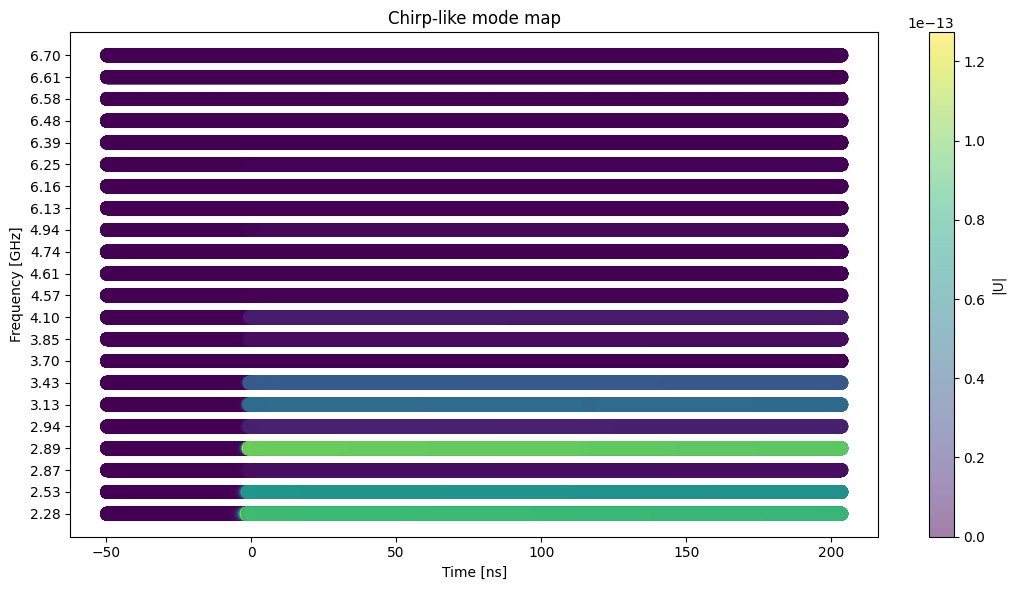

In [4]:
freqs = np.unique(all_f)
y_map = {f: i for i, f in enumerate(freqs)}
all_f_eq = np.array([y_map[f] for f in all_f])

plt.figure(figsize=(11, 6))
sc = plt.scatter(
    all_t,
    all_f_eq,
    c=all_u,
    s=100,
    cmap="viridis",
    alpha=0.5,
    edgecolors="none",
)

plt.xlabel("Time [ns]")
plt.ylabel("Frequency [GHz]")
plt.title("Chirp-like mode map")
plt.yticks(range(len(freqs)), [f"{f:.2f}" for f in freqs])
plt.colorbar(sc, label="|U|")
plt.tight_layout()
plt.show()

In [5]:
target_t_ns = 100.0

print(f"U at t = {target_t_ns:.1f} ns (interpolated per mode):\n")
for key in sorted(loaded_modes.keys(), key=lambda k: loaded_omegas[k]):
    mode_npz = loaded_modes[key]
    t_ns_mode = mode_npz["t"] * 1e9
    U_mode = mode_npz["U"]

    # sort by time for safe interpolation
    s = np.argsort(t_ns_mode)
    t_sorted = t_ns_mode[s]
    U_sorted = U_mode[s]

    if not (t_sorted[0] <= target_t_ns <= t_sorted[-1]):
        print(f"{key:10s}  f={loaded_omegas[key]/(2*np.pi)/1e9:7.3f} GHz  out of range")
        continue

    if np.iscomplexobj(U_sorted):
        U_at_t = np.interp(target_t_ns, t_sorted, U_sorted.real) + 1j * np.interp(
            target_t_ns, t_sorted, U_sorted.imag
        )
    else:
        U_at_t = np.interp(target_t_ns, t_sorted, U_sorted)

    print(
        f"{key:10s}  f={loaded_omegas[key]/(2*np.pi)/1e9:7.3f} GHz  "
        f"U={U_at_t:.6e}  |U|={np.abs(U_at_t):.6e}"
    )

U at t = 100.0 ns (interpolated per mode):

TEa_1,1,1   f=  2.283 GHz  U=4.064844e-14  |U|=4.064844e-14
TEb_1,1,1   f=  2.283 GHz  U=8.648937e-14  |U|=8.648937e-14
TEa_1,1,2   f=  2.527 GHz  U=2.845410e-14  |U|=2.845410e-14
TEb_1,1,2   f=  2.527 GHz  U=6.625639e-14  |U|=6.625639e-14
TMb_0,1,0   f=  2.869 GHz  U=4.202444e-15  |U|=4.202444e-15
TEa_1,1,3   f=  2.887 GHz  U=3.812463e-14  |U|=3.812463e-14
TEb_1,1,3   f=  2.887 GHz  U=9.675933e-14  |U|=9.675933e-14
TMb_0,1,1   f=  2.936 GHz  U=1.149805e-14  |U|=1.149805e-14
TMb_0,1,2   f=  3.129 GHz  U=4.391678e-14  |U|=4.391678e-14
TMb_0,1,3   f=  3.426 GHz  U=3.513959e-14  |U|=3.513959e-14
TEa_2,1,1   f=  3.696 GHz  U=7.167105e-17  |U|=7.167105e-17
TEb_2,1,1   f=  3.696 GHz  U=1.843912e-16  |U|=1.843912e-16
TEa_2,1,2   f=  3.851 GHz  U=2.006372e-15  |U|=2.006372e-15
TEb_2,1,2   f=  3.851 GHz  U=4.651602e-15  |U|=4.651602e-15
TEa_2,1,3   f=  4.097 GHz  U=3.728315e-15  |U|=3.728315e-15
TEb_2,1,3   f=  4.097 GHz  U=9.419523e-15  |U|=9.419523e

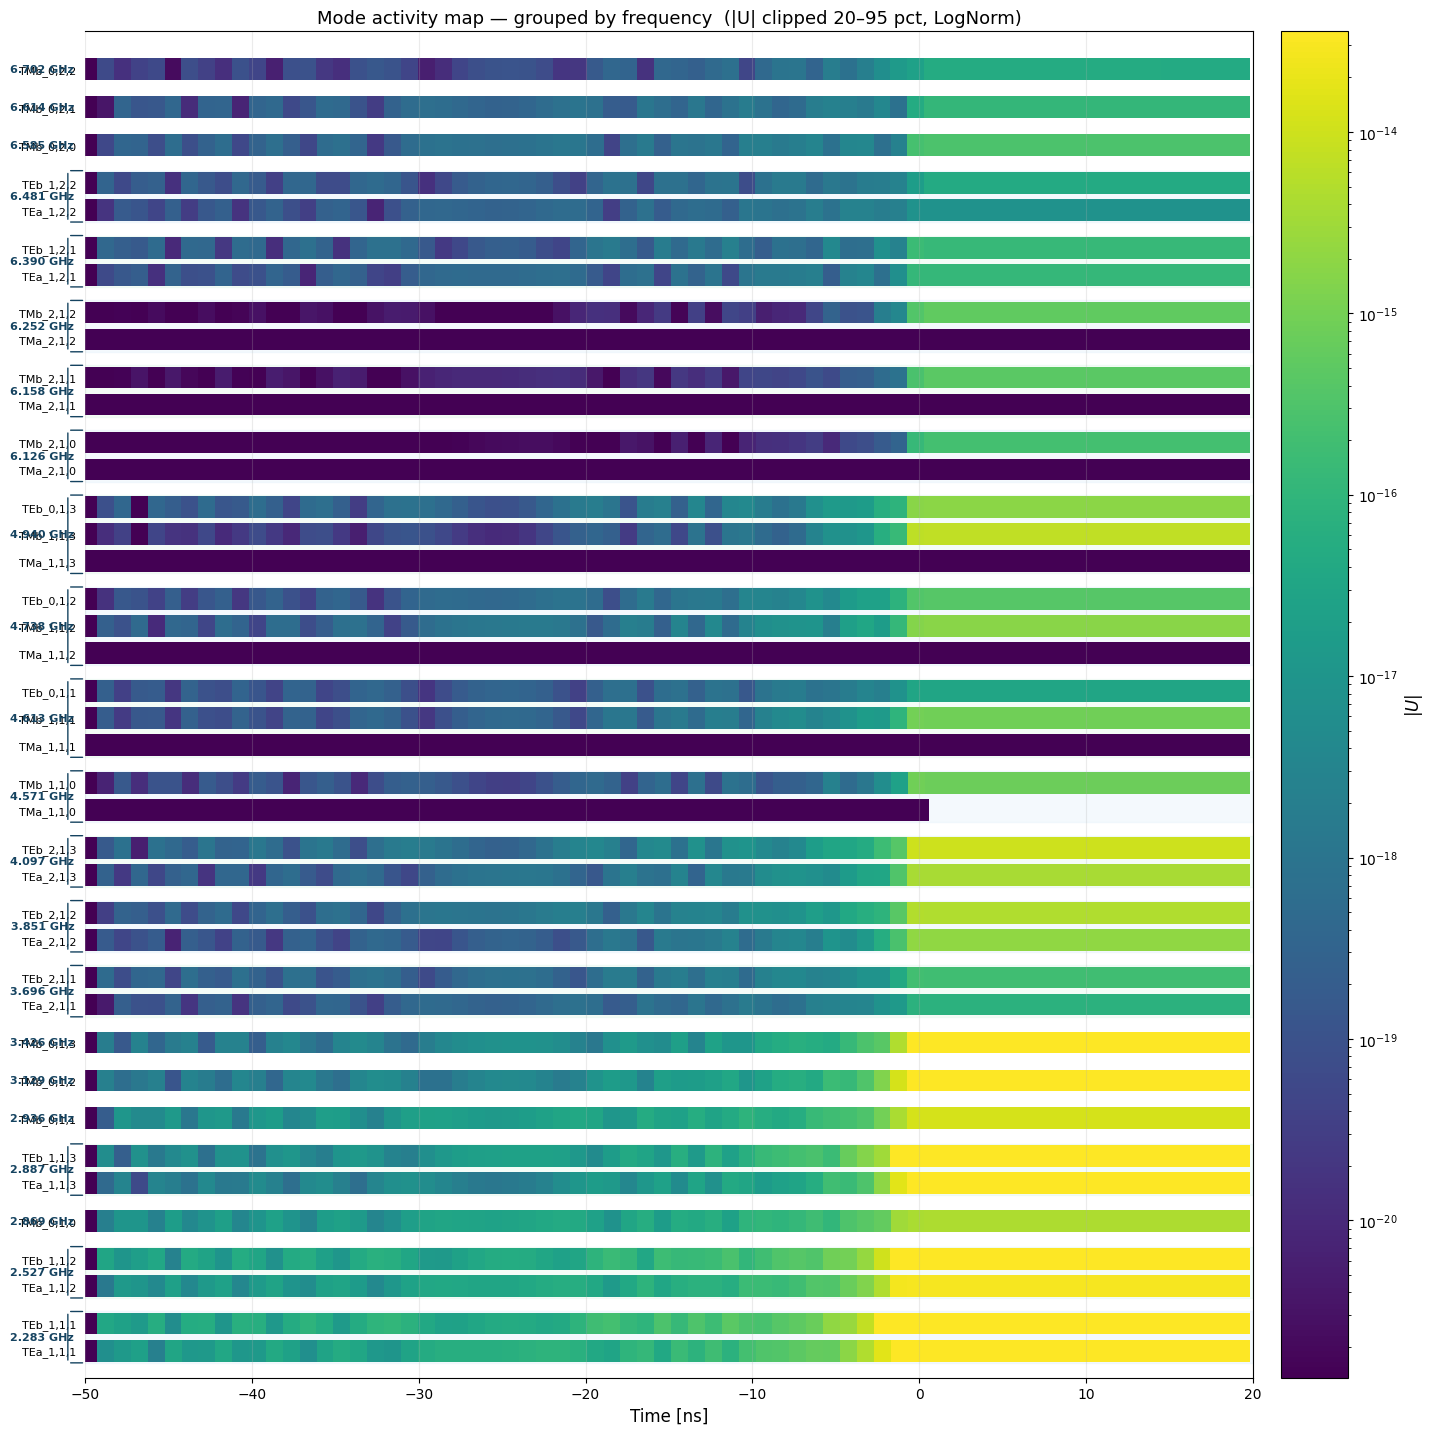

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------
FIGSIZE = (22, 14)
CMAP = "viridis"
KEEP_EVERY = 200
TMIN_NS = -50
TMAX_NS = 20
ABS_LO_PERCENTILE = 20
ABS_HI_PERCENTILE = 95
FREQ_TOL_GHZ = 0.01

# Row height in DATA units — this directly controls separation.
# All markers are drawn with size derived from this (so they always fit).
ROW_HEIGHT = 1.0       # each row occupies this many data units
INNER_GAP  = 0.0       # extra gap between rows IN same group (0 = touching)
OUTER_GAP  = 0.4       # extra gap between groups (in data units)

# ------------------------------------------------------------
# GROUP MODES BY FREQUENCY
# ------------------------------------------------------------
mode_items = sorted(
    loaded_modes.items(),
    key=lambda kv: loaded_omegas[kv[0]]
)

groups = []
for key, _ in mode_items:
    f_ghz = loaded_omegas[key] / (2 * np.pi) / 1e9
    placed = False
    for grp in groups:
        if abs(f_ghz - np.mean([f for _, f in grp])) <= FREQ_TOL_GHZ:
            grp.append((key, f_ghz))
            placed = True
            break
    if not placed:
        groups.append([(key, f_ghz)])

# ------------------------------------------------------------
# ASSIGN Y POSITIONS  (bottom of each row)
# ------------------------------------------------------------
y_positions = {}   # key -> y center
group_info  = []   # (freq_label, [y_centers])

current_y = 0.0
for grp in groups:
    grp_freq   = np.mean([f for _, f in grp])
    freq_label = f"{grp_freq:.3f} GHz"
    ys = []
    for i, (key, _) in enumerate(grp):
        y_positions[key] = current_y
        ys.append(current_y)
        current_y += ROW_HEIGHT + INNER_GAP
    group_info.append((freq_label, ys))
    current_y += OUTER_GAP   # extra space between groups

total_y_range = current_y

# ------------------------------------------------------------
# COLLECT DATA
# ------------------------------------------------------------
all_t, all_y, all_c = [], [], []

for grp in groups:
    for key, _ in grp:
        data = loaded_modes[key]
        t_ns = np.asarray(data["t"]) * 1e9
        U    = np.abs(np.asarray(data["U"]))

        mask = np.isfinite(t_ns) & np.isfinite(U) & (U > 0)
        t_ns, U = t_ns[mask], U[mask]
        if TMIN_NS is not None:
            m = t_ns >= TMIN_NS; t_ns, U = t_ns[m], U[m]
        if TMAX_NS is not None:
            m = t_ns <= TMAX_NS; t_ns, U = t_ns[m], U[m]
        if len(t_ns) == 0:
            continue

        t_ns = t_ns[::KEEP_EVERY]
        U    = U[::KEEP_EVERY]

        all_t.append(t_ns)
        all_y.append(np.full_like(t_ns, y_positions[key]))
        all_c.append(U)

if not all_t:
    raise ValueError("No data after filtering.")

all_t = np.concatenate(all_t)
all_y = np.concatenate(all_y)
all_c = np.concatenate(all_c)

# ------------------------------------------------------------
# COLOR NORM
# ------------------------------------------------------------
good = np.isfinite(all_c) & (all_c > 0)
vals = all_c[good]
vmin = max(np.percentile(vals, ABS_LO_PERCENTILE), np.min(vals[vals > 0]))
vmax = np.percentile(vals, ABS_HI_PERCENTILE)
if vmax <= vmin:
    vmax = np.max(vals)
norm = colors.LogNorm(vmin=vmin, vmax=vmax)

# ------------------------------------------------------------
# COMPUTE MARKER SIZE from figure geometry
# Marker fills exactly ROW_HEIGHT data units vertically,
# with a small inset so adjacent rows have a visible gap.
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=FIGSIZE)

# Set axes limits FIRST so the transform is correct
x_min = TMIN_NS if TMIN_NS is not None else np.min(all_t)
x_max = TMAX_NS if TMAX_NS is not None else np.max(all_t)
ax.set_xlim(x_min, x_max)
ax.set_ylim(-ROW_HEIGHT, total_y_range)

fig.tight_layout()
fig.subplots_adjust(left=0.28)

# Convert ROW_HEIGHT data units → display points
# Use the axes transform: data → display (pixels), then pixels → points
ax.figure.canvas.draw()   # force layout so transforms are valid
y0_disp = ax.transData.transform((0, 0))[1]
y1_disp = ax.transData.transform((0, ROW_HEIGHT))[1]
row_height_px = abs(y1_disp - y0_disp)
row_height_pt = row_height_px * 72.0 / fig.dpi

INSET = 0.10   # fraction of row height left as gap on each side
marker_pt = row_height_pt * (1.0 - 2 * INSET)
MARKER_SIZE = marker_pt ** 2   # scatter s= is in points²

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------
sc = ax.scatter(
    all_t, all_y,
    c=all_c, cmap=CMAP, norm=norm,
    s=MARKER_SIZE, marker="s",
    linewidths=0
)

# ── Y-axis ticks: mode names only ───────────────────────────
ytick_vals = [y_positions[k] for grp in groups for k, _ in grp]
ytick_lbls = [k               for grp in groups for k, _ in grp]
ax.set_yticks(ytick_vals)
ax.set_yticklabels(ytick_lbls, fontsize=8)
ax.tick_params(axis="y", left=False, pad=3)
ax.spines["left"].set_visible(False)

# ── Frequency labels: one per group, left of mode names ─────
for freq_label, ys in group_info:
    y_center = np.mean(ys)
    y_lo     = min(ys)
    y_hi     = max(ys)

    # Frequency label
    ax.annotate(
        freq_label,
        xy=(0, y_center),
        xycoords=("axes fraction", "data"),
        xytext=(-8, 0),
        textcoords="offset points",
        fontsize=8, fontweight="bold", color="#154360",
        va="center", ha="right",
        annotation_clip=False,
    )

    # Bracket spanning the group (only if >1 mode)
    if len(ys) > 1:
        half = (ROW_HEIGHT + INNER_GAP) * 0.45
        bracket_lo = y_lo  - half
        bracket_hi = y_hi  + half
        # Draw as three line segments: top cap, vertical, bottom cap
        cap = 0.015   # length of cap in axes fraction
        for y_cap in [bracket_lo, bracket_hi]:
            ax.annotate("", 
                xy=(0, y_cap), xytext=(-cap, y_cap),
                xycoords=("axes fraction","data"),
                textcoords=("axes fraction","data"),
                arrowprops=dict(arrowstyle="-", color="#154360", lw=1.0),
                annotation_clip=False)
        # Vertical bar
        ax.annotate("",
            xy=(-cap, bracket_lo), xytext=(-cap, bracket_hi),
            xycoords=("axes fraction","data"),
            textcoords=("axes fraction","data"),
            arrowprops=dict(arrowstyle="-", color="#154360", lw=1.0),
            annotation_clip=False)

# ── Faint group bands ────────────────────────────────────────
for i, (_, ys) in enumerate(group_info):
    if len(ys) < 2:
        continue
    half = (ROW_HEIGHT + INNER_GAP) * 0.45
    ax.axhspan(min(ys) - half, max(ys) + half,
               color=["#d6eaf8","#d5f5e3"][i % 2],
               alpha=0.25, zorder=0)

ax.grid(axis="x", alpha=0.25)
ax.set_xlabel("Time [ns]", fontsize=12)
ax.set_title(
    f"Mode activity map — grouped by frequency  "
    f"(|U| clipped {ABS_LO_PERCENTILE}–{ABS_HI_PERCENTILE} pct, LogNorm)",
    fontsize=13,
)

# Increase left margin to give more room for labels/annotations
fig.subplots_adjust(left=0.35)

cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label(r"$|U|$", fontsize=12)

plt.show()

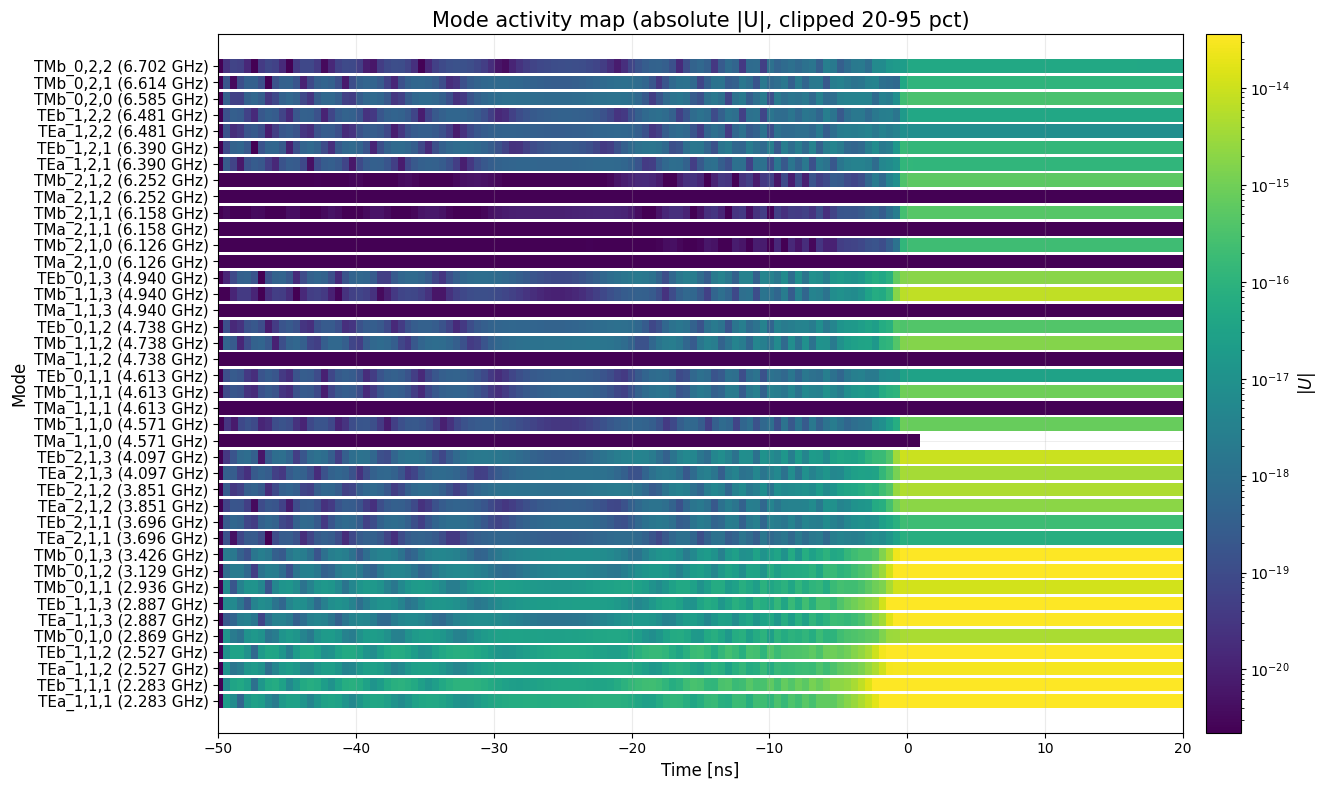

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# ------------------------------------------------------------
# SETTINGS YOU MAY WANT TO CHANGE
# ------------------------------------------------------------
FIGSIZE = (14, 8)

# Large marker size
MARKER_SIZE = 95
MARKER = "s"          # square markers look more like continuous bands
CMAP = "viridis"

# Downsampling per mode (keep every Nth point)
KEEP_EVERY = 100

# Time window to show (set to None to keep full range)
TMIN_NS = -50
TMAX_NS = 20

# Absolute-color settings
ABS_LO_PERCENTILE = 20
ABS_HI_PERCENTILE = 95

# ------------------------------------------------------------
# SORT MODES BY FREQUENCY
# ------------------------------------------------------------
mode_items = sorted(
    loaded_modes.items(),
    key=lambda kv: loaded_omegas[kv[0]]
)

mode_labels = []
all_t = []
all_y = []
all_c = []

for i, (key, data) in enumerate(mode_items):
    t_ns = np.asarray(data["t"]) * 1e9
    U = np.abs(np.asarray(data["U"]))

    f_ghz = loaded_omegas[key] / (2 * np.pi) / 1e9
    mode_labels.append(f"{key} ({f_ghz:.3f} GHz)")

    # Clean finite values
    mask = np.isfinite(t_ns) & np.isfinite(U) & (U > 0)
    t_ns = t_ns[mask]
    U = U[mask]

    # Optional crop in time
    if TMIN_NS is not None:
        mask = t_ns >= TMIN_NS
        t_ns = t_ns[mask]
        U = U[mask]

    if TMAX_NS is not None:
        mask = t_ns <= TMAX_NS
        t_ns = t_ns[mask]
        U = U[mask]

    if len(t_ns) == 0:
        continue

    # IMPORTANT: downsample per mode, not globally
    t_ns = t_ns[::KEEP_EVERY]
    U = U[::KEEP_EVERY]

    # Absolute color values
    cvals = U

    # Equally spaced y rows
    yvals = np.full_like(t_ns, i, dtype=float)

    all_t.append(t_ns)
    all_y.append(yvals)
    all_c.append(cvals)

if len(all_t) == 0:
    raise ValueError("No data points to plot after filtering/downsampling.")

# Concatenate all plotted points
all_t = np.concatenate(all_t)
all_y = np.concatenate(all_y)
all_c = np.concatenate(all_c)

# ------------------------------------------------------------
# CHOOSE COLOR NORMALIZATION (ABSOLUTE ONLY)
# ------------------------------------------------------------
good = np.isfinite(all_c) & (all_c > 0)
vals = all_c[good]

if len(vals) == 0:
    raise ValueError("No positive finite |U| values available for LogNorm.")

vmin = np.percentile(vals, ABS_LO_PERCENTILE)
vmax = np.percentile(vals, ABS_HI_PERCENTILE)

# Protect against pathological cases
vmin = max(vmin, np.min(vals[vals > 0]))
if vmax <= vmin:
    vmax = np.max(vals)

norm = colors.LogNorm(vmin=vmin, vmax=vmax)
cbar_label = r"$|U|$"
title = f"Mode activity map (absolute |U|, clipped {ABS_LO_PERCENTILE}-{ABS_HI_PERCENTILE} pct)"

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=FIGSIZE)

sc = ax.scatter(
    all_t,
    all_y,
    c=all_c,
    cmap=CMAP,
    norm=norm,
    s=MARKER_SIZE,
    marker=MARKER,
    linewidths=0
)

ax.set_yticks(np.arange(len(mode_labels)))
ax.set_yticklabels(mode_labels, fontsize=11)

for y in range(len(mode_labels)):
    ax.axhline(y, color="k", lw=0.4, alpha=0.12, zorder=0)

ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", alpha=0.0)

ax.set_xlabel("Time [ns]", fontsize=12)
ax.set_ylabel("Mode", fontsize=12)
ax.set_title(title, fontsize=15)

if TMIN_NS is not None or TMAX_NS is not None:
    ax.set_xlim(
        TMIN_NS if TMIN_NS is not None else np.min(all_t),
        TMAX_NS if TMAX_NS is not None else np.max(all_t)
    )

cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label(cbar_label, fontsize=12)

plt.tight_layout()
plt.show()


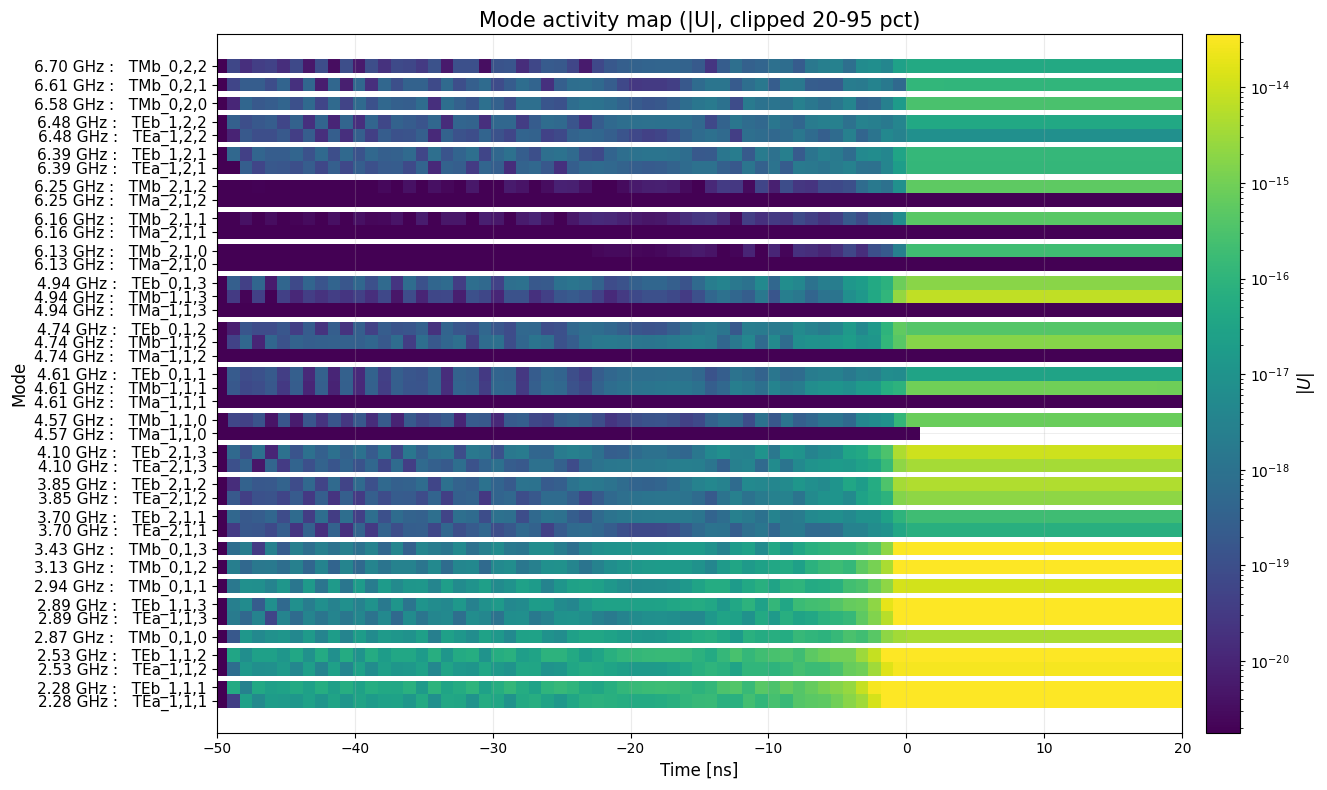

In [109]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# --- settings ---
FIGSIZE = (14, 8)
MARKER_SIZE = 95
MARKER = "s"
CMAP = "viridis"
KEEP_EVERY = 180

TMIN_NS, TMAX_NS = -50, 20
ABS_LO_PERCENTILE, ABS_HI_PERCENTILE = 20, 95

SAME_FREQ_GAP = 4
DIFF_FREQ_GAP = 5.5
FREQ_RTOL, FREQ_ATOL = 1e3, 1e-12

# --- sort modes by frequency ---
mode_items = sorted(loaded_modes.items(), key=lambda kv: loaded_omegas[kv[0]])

mode_labels, mode_y_positions = [], []
prev_freq, y = None, 0.0

for key, _ in mode_items:
    omega = loaded_omegas[key]
    freq = omega / (2*np.pi) / 1e9

    if prev_freq is not None:
        same = abs(freq - prev_freq) < 0.005  # 5 MHz tolerance
        y += SAME_FREQ_GAP if same else DIFF_FREQ_GAP

    mode_y_positions.append(y)
    mode_labels.append(f"{freq:.2f} GHz :   {key}")
    prev_freq = freq

# --- collect plotted points ---
all_t, all_y, all_c = [], [], []

for (key, data), yrow in zip(mode_items, mode_y_positions):
    t_ns = np.asarray(data["t"]) * 1e9
    U = np.abs(np.asarray(data["U"]))

    m = np.isfinite(t_ns) & np.isfinite(U) & (U > 0)
    if TMIN_NS is not None:
        m &= (t_ns >= TMIN_NS)
    if TMAX_NS is not None:
        m &= (t_ns <= TMAX_NS)

    t_ns, U = t_ns[m], U[m]
    if t_ns.size == 0:
        continue

    t_ns, U = t_ns[::KEEP_EVERY], U[::KEEP_EVERY]
    all_t.append(t_ns)
    all_y.append(np.full(t_ns.shape, yrow, dtype=float))
    all_c.append(U)

if not all_t:
    raise ValueError("No data points to plot after filtering/downsampling.")

all_t = np.concatenate(all_t)
all_y = np.concatenate(all_y)
all_c = np.concatenate(all_c)

# --- color normalization (absolute only) ---
vals = all_c[np.isfinite(all_c) & (all_c > 0)]
if vals.size == 0:
    raise ValueError("No positive finite |U| values available for LogNorm.")

vmin = np.percentile(vals, ABS_LO_PERCENTILE)
vmax = np.percentile(vals, ABS_HI_PERCENTILE)
vmin = max(vmin, np.min(vals))
if vmax <= vmin:
    vmax = np.max(vals)

norm = colors.LogNorm(vmin=vmin, vmax=vmax)
title = f"Mode activity map (|U|, clipped {ABS_LO_PERCENTILE}-{ABS_HI_PERCENTILE} pct)"

# --- plot ---
fig, ax = plt.subplots(figsize=FIGSIZE)
sc = ax.scatter(all_t, all_y, c=all_c, cmap=CMAP, norm=norm, s=MARKER_SIZE, marker=MARKER, linewidths=0)

ax.set_yticks(mode_y_positions)
ax.set_yticklabels(mode_labels, fontsize=11)
for yy in mode_y_positions:
    ax.axhline(yy, color="k", lw=0.4, alpha=0.12, zorder=0)

ax.grid(axis="x", alpha=0.25)
ax.set_xlabel("Time [ns]", fontsize=12)
ax.set_ylabel("Mode", fontsize=12)
ax.set_title(title, fontsize=15)

if TMIN_NS is not None or TMAX_NS is not None:
    ax.set_xlim(
        TMIN_NS if TMIN_NS is not None else all_t.min(),
        TMAX_NS if TMAX_NS is not None else all_t.max()
    )

cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label(r"$|U|$", fontsize=12)

plt.tight_layout()
plt.show()


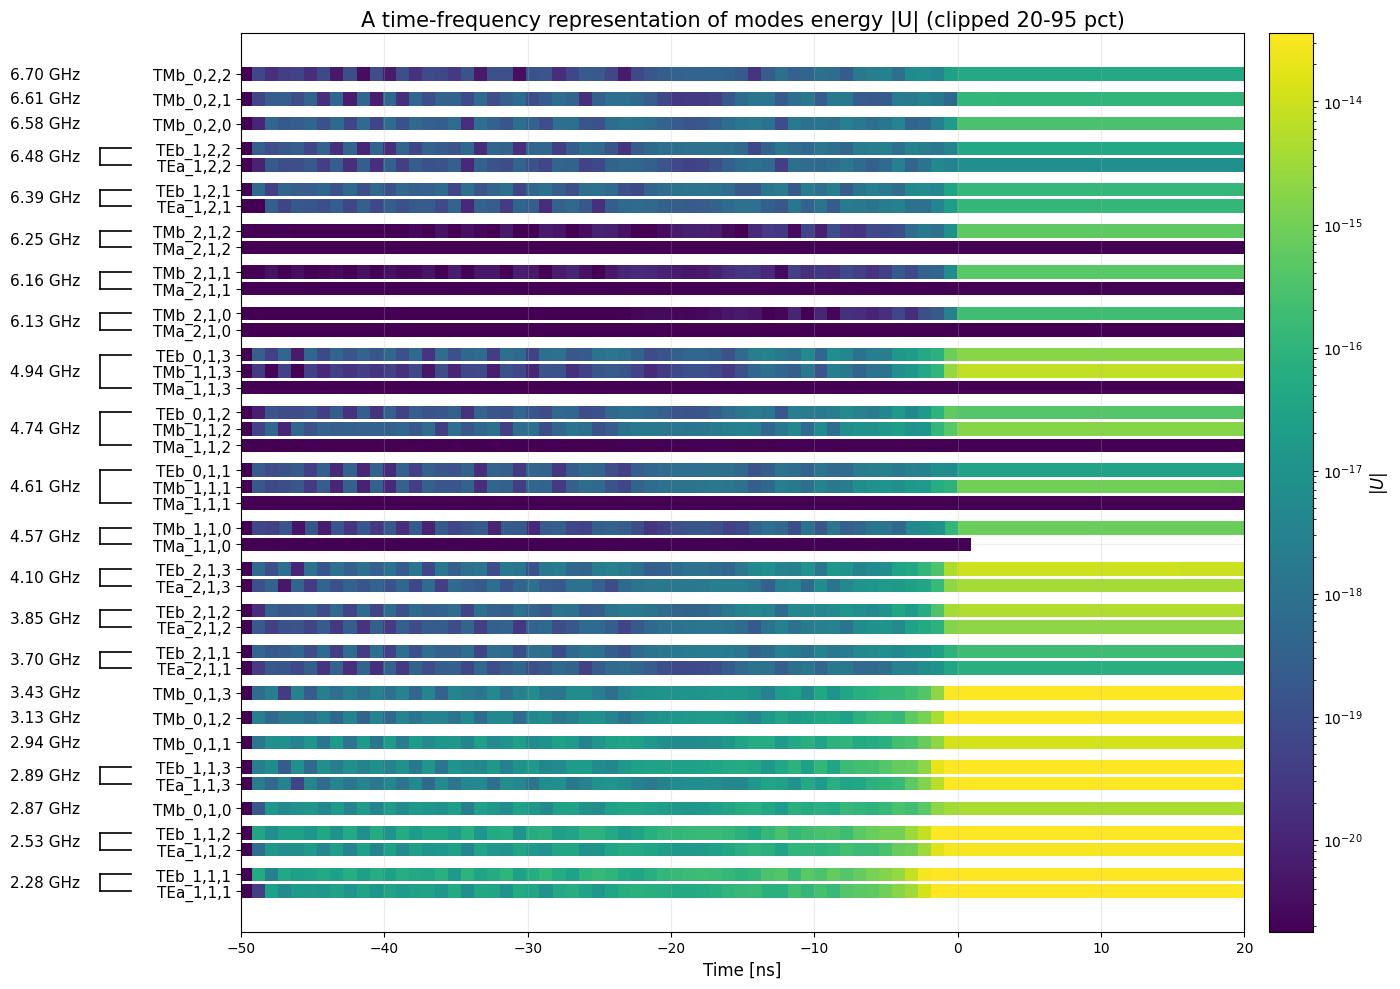

In [135]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.transforms as transforms

# --- settings ---
FIGSIZE = (17,10)
MARKER_SIZE = 95
MARKER = "s"
CMAP = "viridis"
KEEP_EVERY = 180

TMIN_NS, TMAX_NS = -50, 20
ABS_LO_PERCENTILE, ABS_HI_PERCENTILE = 20, 95

SAME_FREQ_GAP = 2
DIFF_FREQ_GAP = 3
FREQ_TOL_GHZ = 0.005   # 5 MHz

# --- sort modes by frequency ---
mode_items = sorted(loaded_modes.items(), key=lambda kv: loaded_omegas[kv[0]])

mode_names = []
mode_freqs = []
mode_y_positions = []

prev_freq, y = None, 0.0
for key, _ in mode_items:
    omega = loaded_omegas[key]
    freq = omega / (2*np.pi) / 1e9

    if prev_freq is not None:
        same = abs(freq - prev_freq) < FREQ_TOL_GHZ
        y += SAME_FREQ_GAP if same else DIFF_FREQ_GAP

    mode_names.append(str(key))         # only mode name on y tick
    mode_freqs.append(freq)
    mode_y_positions.append(y)
    prev_freq = freq

# --- build frequency groups ---
freq_groups = []   # list of dicts: {'freq':..., 'start':..., 'end':..., 'y0':..., 'y1':..., 'yc':...}

start = 0
for i in range(1, len(mode_freqs) + 1):
    is_break = (
        i == len(mode_freqs)
        or abs(mode_freqs[i] - mode_freqs[i - 1]) >= FREQ_TOL_GHZ
    )
    if is_break:
        y0 = mode_y_positions[start]
        y1 = mode_y_positions[i - 1]
        yc = 0.5 * (y0 + y1)
        freq_groups.append({
            "freq": mode_freqs[start],
            "start": start,
            "end": i - 1,
            "y0": y0,
            "y1": y1,
            "yc": yc,
        })
        start = i

# --- collect plotted points ---
all_t, all_y, all_c = [], [], []

for (key, data), yrow in zip(mode_items, mode_y_positions):
    t_ns = np.asarray(data["t"]) * 1e9
    U = np.abs(np.asarray(data["U"]))
    m = np.isfinite(t_ns) & np.isfinite(U) & (U > 0)

    if TMIN_NS is not None:
        m &= (t_ns >= TMIN_NS)
    if TMAX_NS is not None:
        m &= (t_ns <= TMAX_NS)

    t_ns, U = t_ns[m], U[m]
    if t_ns.size == 0:
        continue

    t_ns, U = t_ns[::KEEP_EVERY], U[::KEEP_EVERY]
    all_t.append(t_ns)
    all_y.append(np.full(t_ns.shape, yrow, dtype=float))
    all_c.append(U)

if not all_t:
    raise ValueError("No data points to plot after filtering/downsampling.")

all_t = np.concatenate(all_t)
all_y = np.concatenate(all_y)
all_c = np.concatenate(all_c)

# --- color normalization (absolute only) ---
vals = all_c[np.isfinite(all_c) & (all_c > 0)]
if vals.size == 0:
    raise ValueError("No positive finite |U| values available for LogNorm.")

vmin = np.percentile(vals, ABS_LO_PERCENTILE)
vmax = np.percentile(vals, ABS_HI_PERCENTILE)
vmin = max(vmin, np.min(vals))
if vmax <= vmin:
    vmax = np.max(vals)

norm = colors.LogNorm(vmin=vmin, vmax=vmax)
title = f"A time-frequency representation of modes energy |U| (clipped {ABS_LO_PERCENTILE}-{ABS_HI_PERCENTILE} pct)"

# --- plot ---
fig, ax = plt.subplots(figsize=FIGSIZE)
sc = ax.scatter(
    all_t, all_y, c=all_c, cmap=CMAP, norm=norm,
    s=MARKER_SIZE, marker=MARKER, linewidths=0
)

# normal y tick labels: mode names only
ax.set_yticks(mode_y_positions)
ax.set_yticklabels(mode_names, fontsize=11)

# faint row guides
for yy in mode_y_positions:
    ax.axhline(yy, color="k", lw=0.4, alpha=0.12, zorder=0)

ax.grid(axis="x", alpha=0.25)
ax.set_xlabel("Time [ns]", fontsize=12)
#ax.set_ylabel("Mode", fontsize=12)
ax.set_title(title, fontsize=15)

if TMIN_NS is not None or TMAX_NS is not None:
    ax.set_xlim(
        TMIN_NS if TMIN_NS is not None else all_t.min(),
        TMAX_NS if TMAX_NS is not None else all_t.max()
    )

# --- draw combined frequency labels on the far left ---
# x in axes coordinates, y in data coordinates
trans = transforms.blended_transform_factory(ax.transAxes, ax.transData)

x_text = -0.16   # frequency text position (left of axis)
x_line = -0.04   # bracket vertical line
x_hook = -0.025  # little horizontal hooks

x_text = -0.16
x_line = -0.14
x_hook = -0.11

for g in freq_groups:
    # bold combined frequency label
    ax.text(
        x_text, g["yc"], f'{g["freq"]:.2f} GHz',
        transform=trans,
        ha="right", va="center",
        fontsize=11, fontweight="normal", color="black",
        clip_on=False
    )

    #draw bracket only if group has multiple rows
    if g["end"] > g["start"]:
        ax.plot([x_line, x_line], [g["y0"], g["y1"]],
                transform=trans, color="black", lw=1.2, clip_on=False)
        ax.plot([x_line, x_hook], [g["y0"], g["y0"]],
                transform=trans, color="black", lw=1.2, clip_on=False)
        ax.plot([x_line, x_hook], [g["y1"], g["y1"]],
                transform=trans, color="black", lw=1.2, clip_on=False)

cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label(r"$|U|$", fontsize=12)

# extra left margin for grouped frequency labels
plt.tight_layout()
fig.subplots_adjust(left=0.28)

plt.show()